# Mobile App Success Analytics Using Python

## A Data Science Project using Google Play Store Dataset

## Introduction

The Google Play Store contains thousands of mobile applications across different categories. Understanding factors such as ratings, reviews, installs, pricing, and categories can help identify the characteristics of successful applications.

This project performs Exploratory Data Analysis (EDA) on Google Play Store data using Python libraries such as Pandas, Matplotlib, and Seaborn to uncover useful insights about app performance.

## Objectives

- Analyze the Google Play Store dataset.
- Perform data cleaning and preprocessing.
- Study app ratings and their distribution.
- Compare free and paid applications.
- Identify categories with the highest installs.
- Determine the highest-rated app categories.
- Discover factors that contribute to app success.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Complete")

Setup Complete


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
import os

print(os.getcwd())
print(os.listdir())


c:\Users\Sravya Prodduturi\Desktop\App Insight
['googleplaystore.csv', 'googleplaystore.csv.zip', 'Mobile_App_Success_Analytics.ipynb']


In [6]:
import os

print(os.path.isfile("googleplaystore.csv"))
print(os.path.getsize("googleplaystore.csv"))

False
0


In [7]:
import os

print(os.listdir())

['googleplaystore.csv', 'googleplaystore.csv.zip', 'Mobile_App_Success_Analytics.ipynb']


In [8]:
import os

for file in os.listdir():
    print(file, "| Is File:", os.path.isfile(file), "| Size:", os.path.getsize(file))

googleplaystore.csv | Is File: False | Size: 0
googleplaystore.csv.zip | Is File: True | Size: 319016
Mobile_App_Success_Analytics.ipynb | Is File: True | Size: 0


In [9]:
import os

print(os.listdir("googleplaystore.csv"))

['google_play_store_dataset.csv']


## Dataset Loading

In [10]:
import pandas as pd

df = pd.read_csv("googleplaystore.csv/google_play_store_dataset.csv")

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Dataset Overview

In [11]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(10841, 13)


In [12]:
print(df.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


## Data Cleaning

Missing values were removed and important columns were converted into appropriate data types for analysis.

In [14]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [16]:
df = df.dropna()

In [17]:
print(df.shape)

(9360, 13)


In [18]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [19]:
print(df.shape)

(9360, 13)


In [20]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [21]:
df['Reviews'] = pd.to_numeric(df['Reviews'])

In [22]:
print(df['Reviews'].dtype)

int64


In [23]:
df['Installs'] = df['Installs'].str.replace('+','', regex=False)
df['Installs'] = df['Installs'].str.replace(',','')
df['Installs'] = df['Installs'].astype(int)

In [24]:
df['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [25]:
df['Price'] = df['Price'].str.replace('$','', regex=False)
df['Price'] = pd.to_numeric(df['Price'])

In [26]:
print(df['Price'].dtype)

float64


In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 9360 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9360 non-null   str    
 1   Category        9360 non-null   str    
 2   Rating          9360 non-null   float64
 3   Reviews         9360 non-null   int64  
 4   Size            9360 non-null   str    
 5   Installs        9360 non-null   int64  
 6   Type            9360 non-null   str    
 7   Price           9360 non-null   float64
 8   Content Rating  9360 non-null   str    
 9   Genres          9360 non-null   str    
 10  Last Updated    9360 non-null   str    
 11  Current Ver     9360 non-null   str    
 12  Android Ver     9360 non-null   str    
dtypes: float64(2), int64(2), str(9)
memory usage: 1023.8 KB


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("googleplaystore.csv/google_play_store_dataset.csv")

In [4]:
df = df.dropna()

In [5]:
df['Reviews'] = pd.to_numeric(df['Reviews'])

In [6]:
df['Installs'] = df['Installs'].str.replace('+','', regex=False)
df['Installs'] = df['Installs'].str.replace(',','')
df['Installs'] = df['Installs'].astype(int)

In [7]:
df['Price'] = df['Price'].str.replace('$','', regex=False)
df['Price'] = pd.to_numeric(df['Price'])

In [8]:
print(df.shape)

(9360, 13)


## Visualization 1: Top 10 App Categories

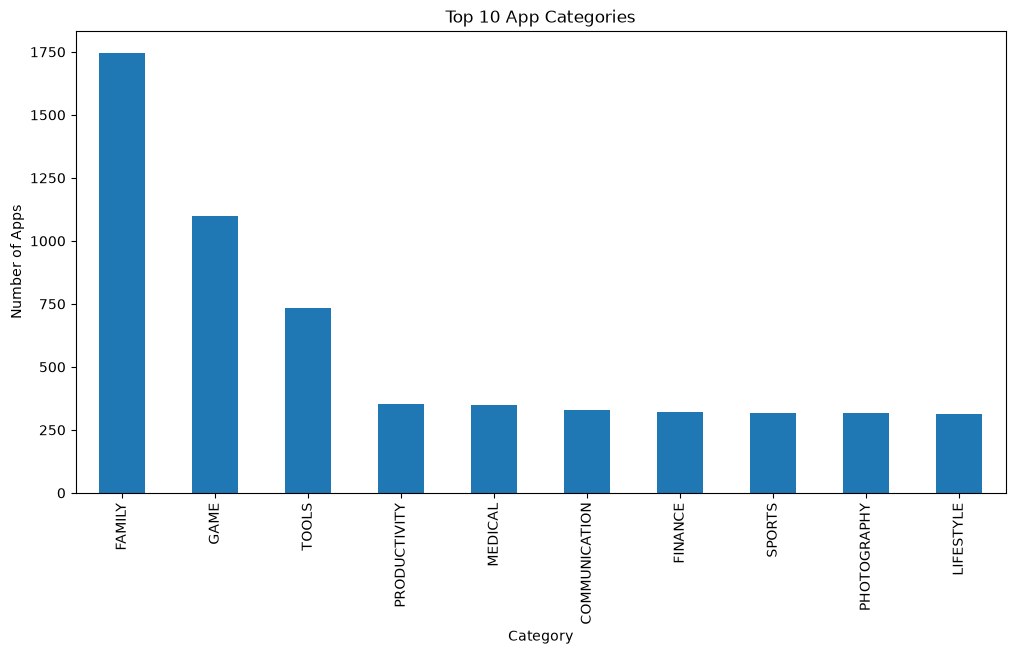

In [9]:
plt.figure(figsize=(12,6))

df['Category'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.show()

Insight:

The FAMILY category contains the highest number of applications on the Google Play Store, followed by GAME and TOOLS. This indicates that family-oriented and entertainment applications dominate the platform.

## Visualization 2: Distribution of App Ratings

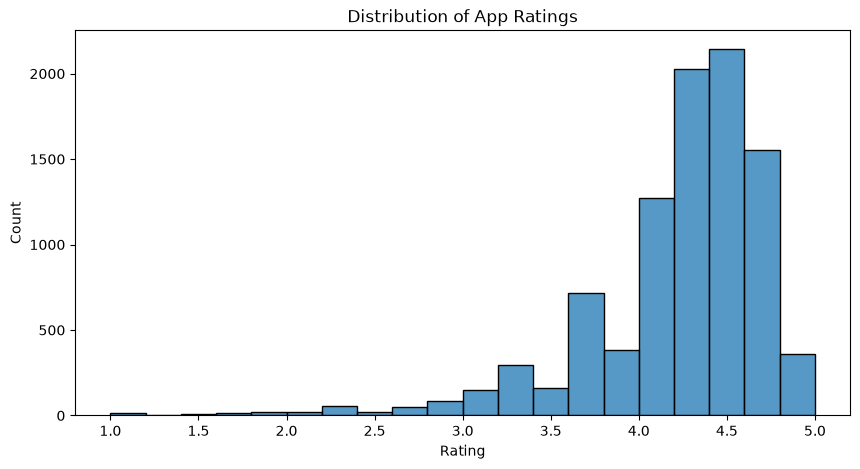

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(df['Rating'], bins=20)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

Insight:

Most applications on the Google Play Store have ratings between 4.0 and 4.8, with the highest concentration around 4.5. This suggests that users generally rate apps positively, while low-rated apps are comparatively rare.

## Visualization 3: Free vs Paid Applications

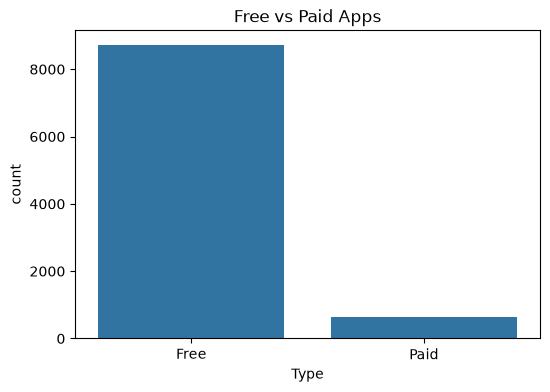

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x='Type', data=df)

plt.title("Free vs Paid Apps")

plt.show()

Insight:

The majority of applications on the Google Play Store are free. Paid applications represent only a small percentage of the total apps available, indicating that the free-app business model is the most popular among developers.

## Visualization 4: Top Categories by Total Installs

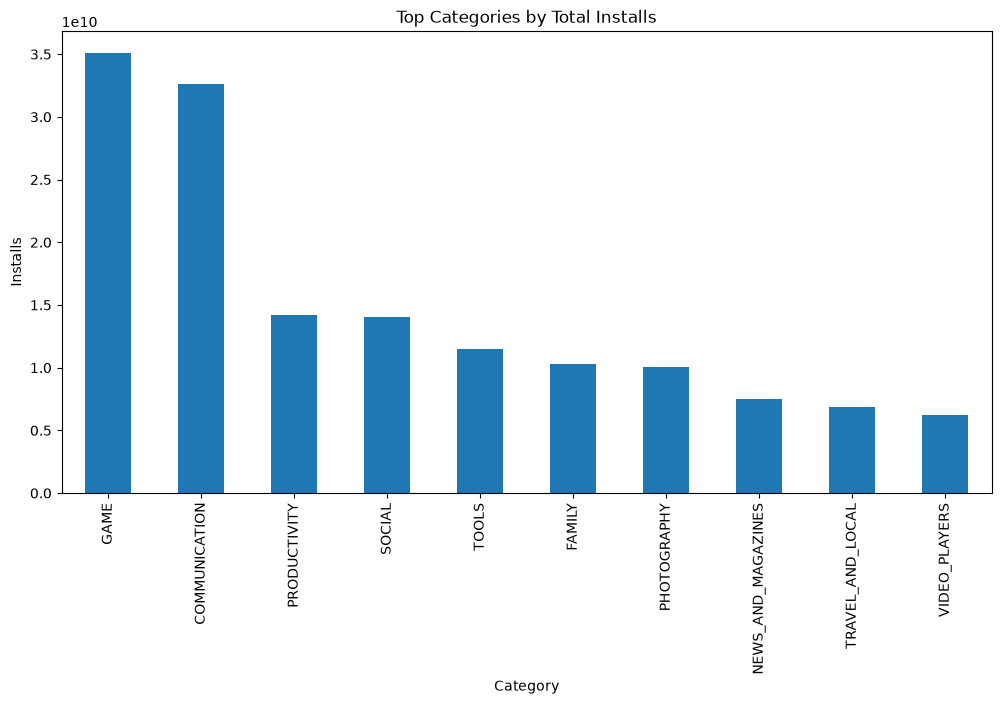

In [12]:
top_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_installs.plot(kind='bar')

plt.title("Top Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Installs")

plt.show()

Insight:

The GAME and COMMUNICATION categories have the highest total installs on the

## Visualization 5: Reviews vs Installs Relationship

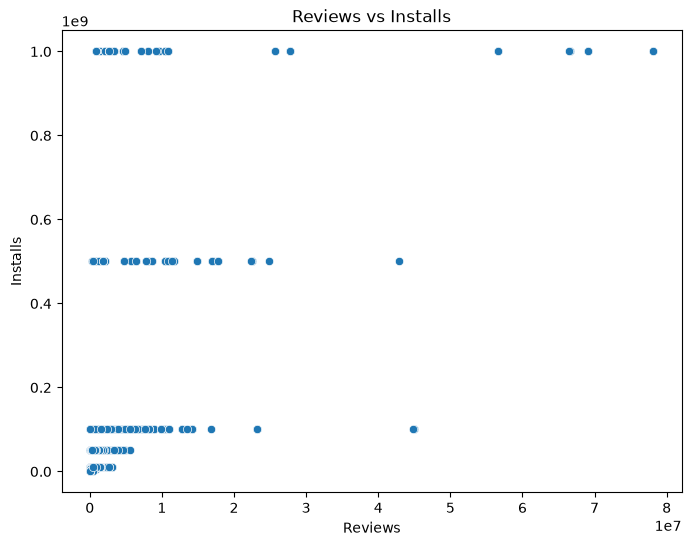

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Reviews',
    y='Installs',
    data=df
)

plt.title("Reviews vs Installs")
plt.xlabel("Reviews")
plt.ylabel("Installs")

plt.show()

Insight:

A positive relationship exists between reviews and installs. Applications with a higher number of reviews generally tend to have more installations, indicating that popular apps attract greater user engagement.

## Visualization 6: Top Categories by Average Rating

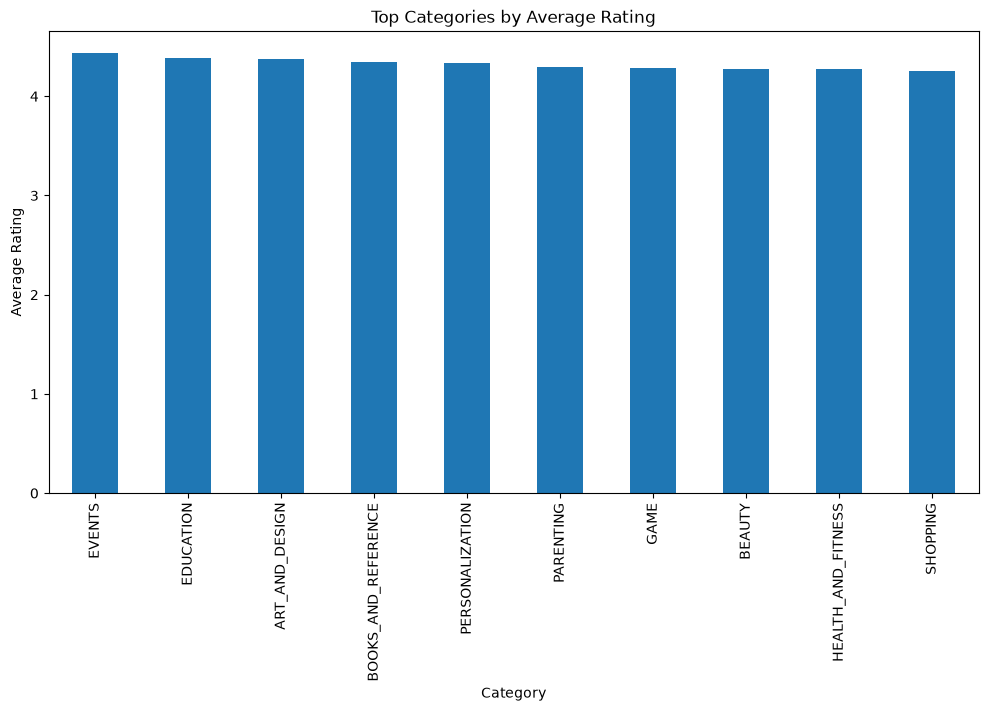

In [14]:
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

avg_rating.plot(kind='bar')

plt.title("Top Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.show()

In [ ]:
Insight:

The EVENTS category has the highest average rating among all categories. Categories such as EDUCATION, ART & DESIGN, PARENTING, and PERSONALIZATION also maintain high user ratings, indicating strong user satisfaction.

## Visualization 7: Most Reviewed Applications

In [15]:
top_reviews = df[['App','Reviews']].sort_values(
    by='Reviews',
    ascending=False
).head(10)

top_reviews

,App,Reviews
2544,Facebook,78158306
3943,Facebook,78128208
381,WhatsApp Messenger,69119316
336,WhatsApp Messenger,69119316
3904,WhatsApp Messenger,69109672
2604,Instagram,66577446
2545,Instagram,66577313
2611,Instagram,66577313
3909,Instagram,66509917
382,Messenger – Text and Video Chat for Free,56646578


Insight:

Facebook, WhatsApp Messenger, Instagram, and Messenger are the most reviewed applications on the Google Play Store. These applications have tens of millions of reviews, reflecting their massive user bases and global popularity.

# Key Insights

1. FAMILY is the category with the highest number of apps.

2. Most applications have ratings between 4.0 and 4.8.

3. Free applications significantly outnumber paid applications.

4. GAME and COMMUNICATION categories have the highest total installs.

5. Applications with more reviews generally receive more installs.

6. EVENTS category has the highest average rating.

7. User ratings are generally positive across most categories.

# Conclusion

This project analyzed Google Play Store applications using Python, Pandas, Matplotlib, and Seaborn.

The dataset was cleaned and explored to identify trends in app categories, ratings, installs, reviews, and pricing.

The analysis revealed that FAMILY is the most common category, free apps dominate the marketplace, and GAME and COMMUNICATION apps achieve the highest installation counts. Most apps maintain ratings above 4.0, demonstrating overall positive user satisfaction.

These insights can help developers and businesses better understand app market trends and user preferences.